# Decaimiento radiactivo y fluctuaciones estadísticas
---

En un experimento de física nuclear, se detecta la radiación de una fuente radiactiva con un contador Geiger. El número de partículas detectadas en un intervalo de tiempo fijo sigue una distribución de Poisson debido a la naturaleza aleatoria del decaimiento radiactivo. Supongamos que la tasa media de detección es de **5 partículas por segundo**.

**(a)** Si se realizan mediciones de 1 segundo de duración, ¿cuál es la probabilidad de detectar exactamente 3 partículas en un segundo?

**(b)** Simular **1000 mediciones** de 1 segundo, suponiendo que el número de partículas detectadas en cada segundo sigue una distribución de Poisson con media $ \lambda = 5 $.

- Construir un histograma de frecuencias con los resultados simulados.
- Comparar visualmente con la función de probabilidad teórica de Poisson.

**(c)** Calcular la media y la varianza de los datos simulados y comparar con los valores teóricos esperados $ \mu = \lambda $, $ \sigma^2 = \lambda $.

**(d)** Repetir la simulación pero ahora con mediciones de **10 segundos**, de modo que el número total de partículas detectadas en ese intervalo siga una Poisson con media $ \lambda = 50 $. Graficar el histograma y comparar con una distribución normal de media 50 y varianza 50 (aproximación gaussiana). Observar cómo al aumentar la media, la distribución de Poisson se aproxima a una normal.

## Modelo
---

Queremos describir la cantidad $X$ de particulas que pasan por el detector durante un lapso de tiempo dado. Dado que la probabilidad de emision de una particula en un intervalo $\Delta t$ es proporcional a la longitud de intervalo, con proporcionalidad $\alpha$, decimos que tenemos un proceso de Poisson. Entonces describimos a esta variable aleatoria con la distribucion de Poisson con parametro $\mu$:

\begin{equation}
p(x,\mu) = \frac{\mu ^x e^{-\mu}}{x!}
\end{equation}

donde $\mu = V(X)$ es el valor esperado o valor medio de la variable $X$. Para el caso de un proceso de Poisson $\mu = \alpha t$. En este caso se nos acalra que tenemos una tasa o rapidez de $\alpha = 5 s^{-1}$. 

## (a)
---

Si realizamos mediciones de un segundo esperamos medir 5 particulas, ya que en este caso $\mu = (5 s^{-1}) 1s = 5$. La probabilidad d emedir exactamente 3 particulas es entonces:

\begin{equation}
    p(x=3, \mu=5) = \frac{5 ^3 e^{-5}}{3!} = 0,1404
\end{equation}

es decir, la probabilidad de medir 3 particulas en 1 segundo es de 14%

In [3]:
from scipy.stats import poisson, norm
import numpy as np
import matplotlib.pyplot as plt

In [4]:
proba_a = round(poisson.pmf(3,5), 4)

print(f'La probabilidad de medir 3 particulas en 1 segundo es {100*proba_a}%')

La probabilidad de medir 3 particulas en 1 segundo es 14.04%


## (b)
---

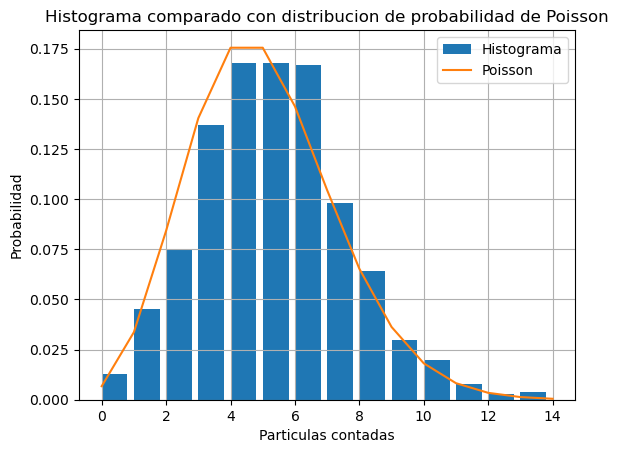

In [5]:
# Defino la variable aleatoria con mu = 5 y n = 1000
particulas = np.random.poisson(5,1000)
particulas

fig, ax = plt.subplots(1,1)

# Histograma de datos simulados
ax.hist(particulas, bins=range(15), density=True, width=0.8, label='Histograma')

# Poisson PMF
x = np.arange(0,15)
ax.plot(poisson.pmf(x,5), label='Poisson')

# Etiquetas de figura
ax.legend()
ax.set_title('Histograma comparado con distribucion de probabilidad de Poisson')
ax.set_xlabel('Particulas contadas')
ax.set_ylabel('Probabilidad')
ax.grid(True)

## (c)
---

In [6]:
media = np.mean(particulas)
varianza = np.var(particulas)

print(f"La media de la variable 'particulas' es: {media}")
print(f"La varianza de la variable 'particulas' es: {varianza}")

La media de la variable 'particulas' es: 4.966
La varianza de la variable 'particulas' es: 5.274843999999999


## (d)
---

Si ahora aumentamos el tiempo de medicion a 10 segundos tenemos $\mu = 50$.

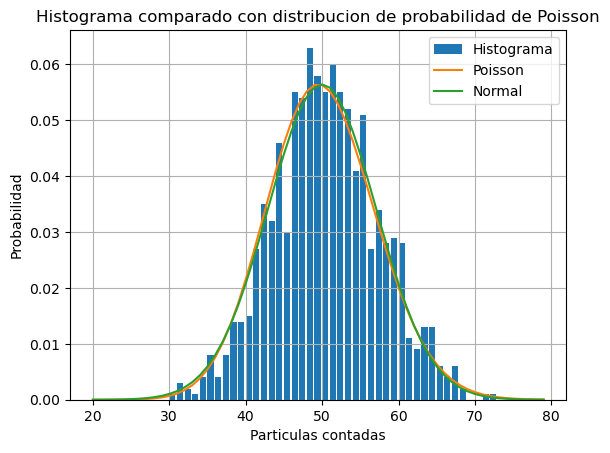

In [7]:
# Defino la variable aleatoria con \mu = 50 y n = 1000
particulas_10 = np.random.poisson(50,1000)

fig1, ax1 = plt.subplots(1,1)

# Histograma de datos simulados
ax1.hist(particulas_10, bins=range(20,80), density=True, width=0.8, label='Histograma')

# Poisson PMF
x = np.arange(20,80)
ax1.plot(x, poisson.pmf(x,50), label='Poisson')

# Normal PDF
ax1.plot(x, norm.pdf(x, 50, np.sqrt(50)), label='Normal')

# Etiquetas de figura
ax1.legend()
ax1.set_title('Histograma comparado con distribucion de probabilidad de Poisson')
ax1.set_xlabel('Particulas contadas')
ax1.set_ylabel('Probabilidad')
ax1.grid(True)

Podemos generar cuatro distrubciones con medias incrementales para ilustrar que a medida que la media aumenta la distribucion de Poisson se aproxima a una normal o gausseana con la misma media y varianza.


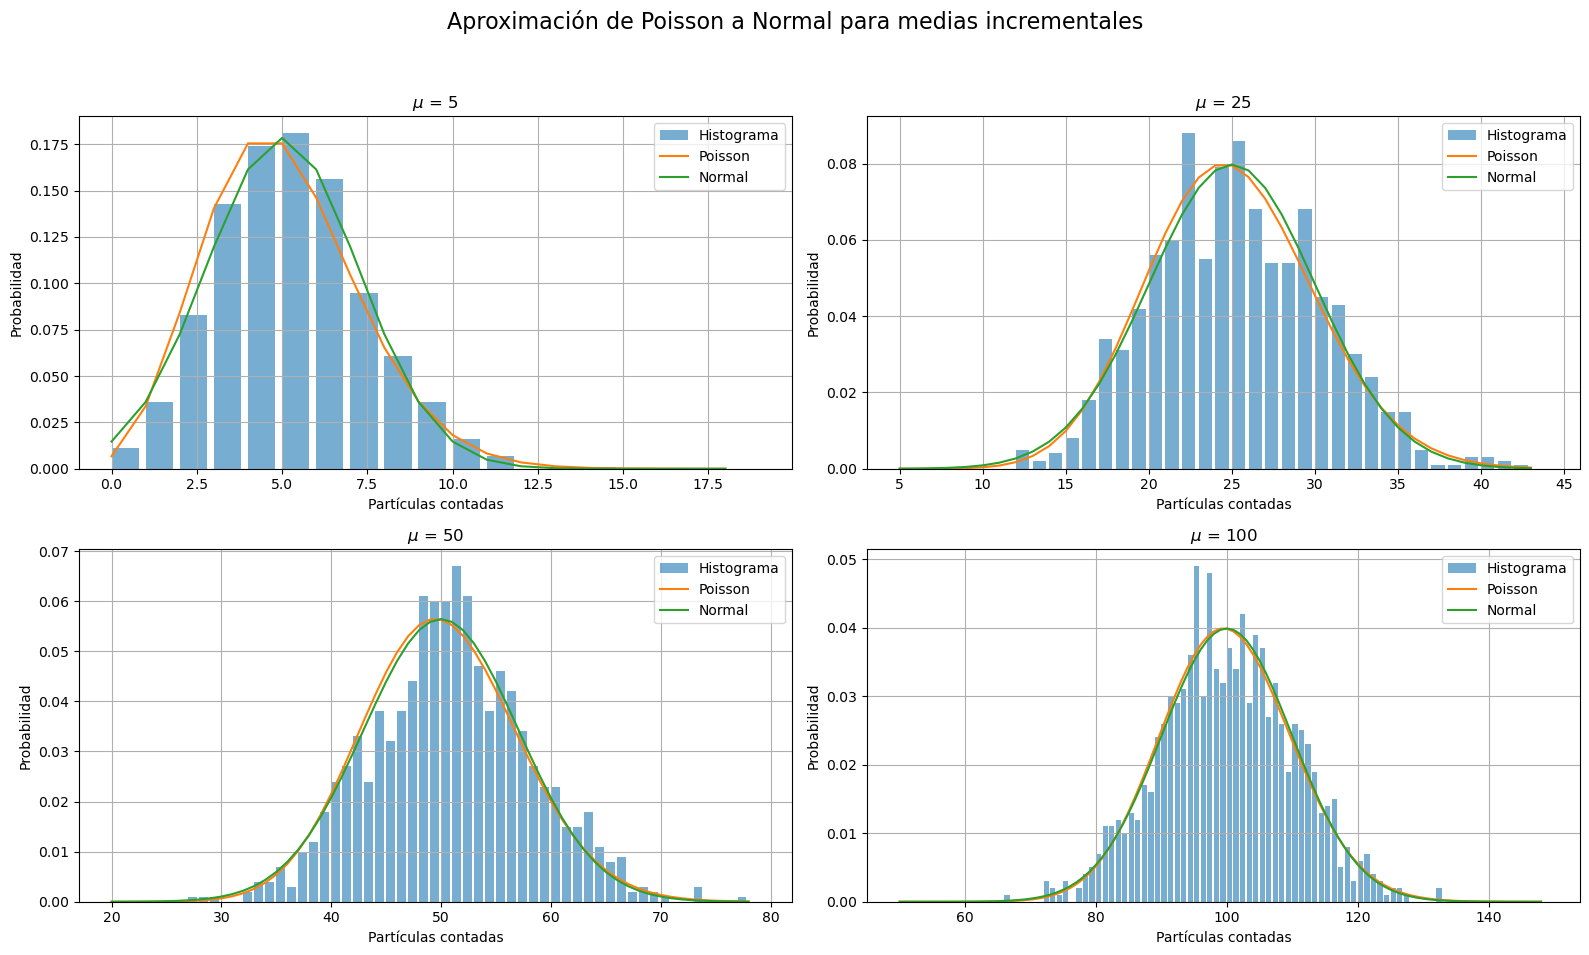

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
mus = [5, 25, 50, 100]
n = 1000
bins_list = [range(0, 20), range(5, 45), range(20, 80), range(50, 150)]

for idx, mu in enumerate[int](mus):
    particulas_d = np.random.poisson(mu, n)
    ax = axs[idx // 2, idx % 2]
    bins = bins_list[idx]

    # Histograma de los datos simulados
    ax.hist(particulas_d, bins=bins, density=True, width=0.8, alpha=0.6, label='Histograma')

    # Poisson PMF
    x = np.arange(min(bins), max(bins))
    ax.plot(x, poisson.pmf(x, mu), label='Poisson')

    # Normal PDF (con media y varianza = mu)
    ax.plot(x, norm.pdf(x, mu, np.sqrt(mu)), label='Normal')

    ax.set_title(f'$\mu$ = {mu}')
    ax.set_xlabel('Partículas contadas')
    ax.set_ylabel('Probabilidad')
    ax.grid(True)
    ax.legend()

fig.suptitle('Aproximación de Poisson a Normal para medias incrementales', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()